In [83]:
import multiprocessing as mp
from functools import partial
import os

import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from tqdm import tqdm

import DMdecay as dmd
import JWSTutils as jwst
from gnz11_split import partition_gnz11

In [84]:
run_dir = "gnz11_split"
prev_config_path = F"{run_dir}/gnz11_split.toml"

In [85]:
prev_configs = dmd.prep.parse_configs(prev_config_path)
run_name = prev_configs["run"]["name"]

data = jwst.process_datafiles(prev_configs["run"]["paths"], 
                                prev_configs["system"]["res_path"])
data = partition_gnz11(data, prev_configs["run"]["lambda_min"],
                        prev_configs["run"]["lambda_split"])
for spec in data:
    dmd.prep.doppler_correction(spec, prev_configs["halo"])
    dmd.prep.add_Dfactor(spec, prev_configs["halo"])

parsing gnz11_split/gnz11_split.toml
processing 2 datafiles...


Text(0.5, 1.0, 'Relative Error Spectrum')

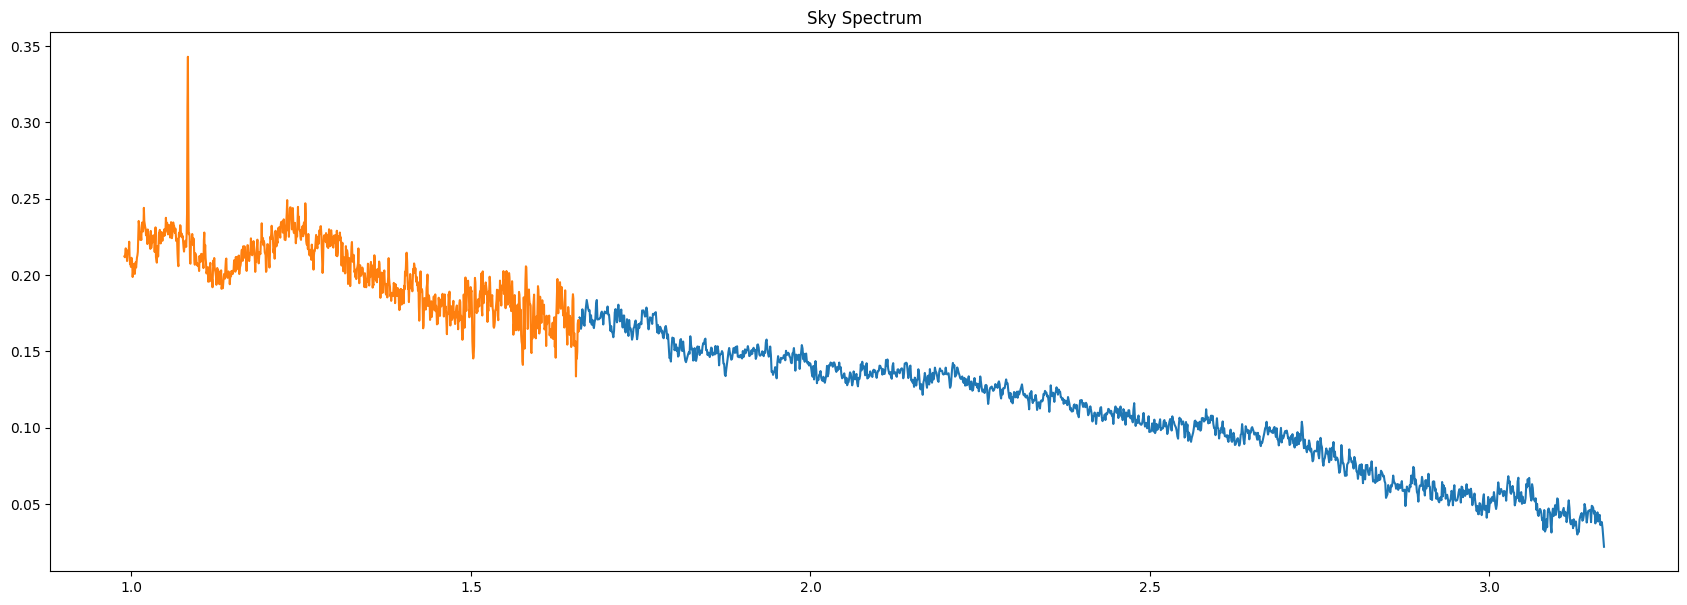

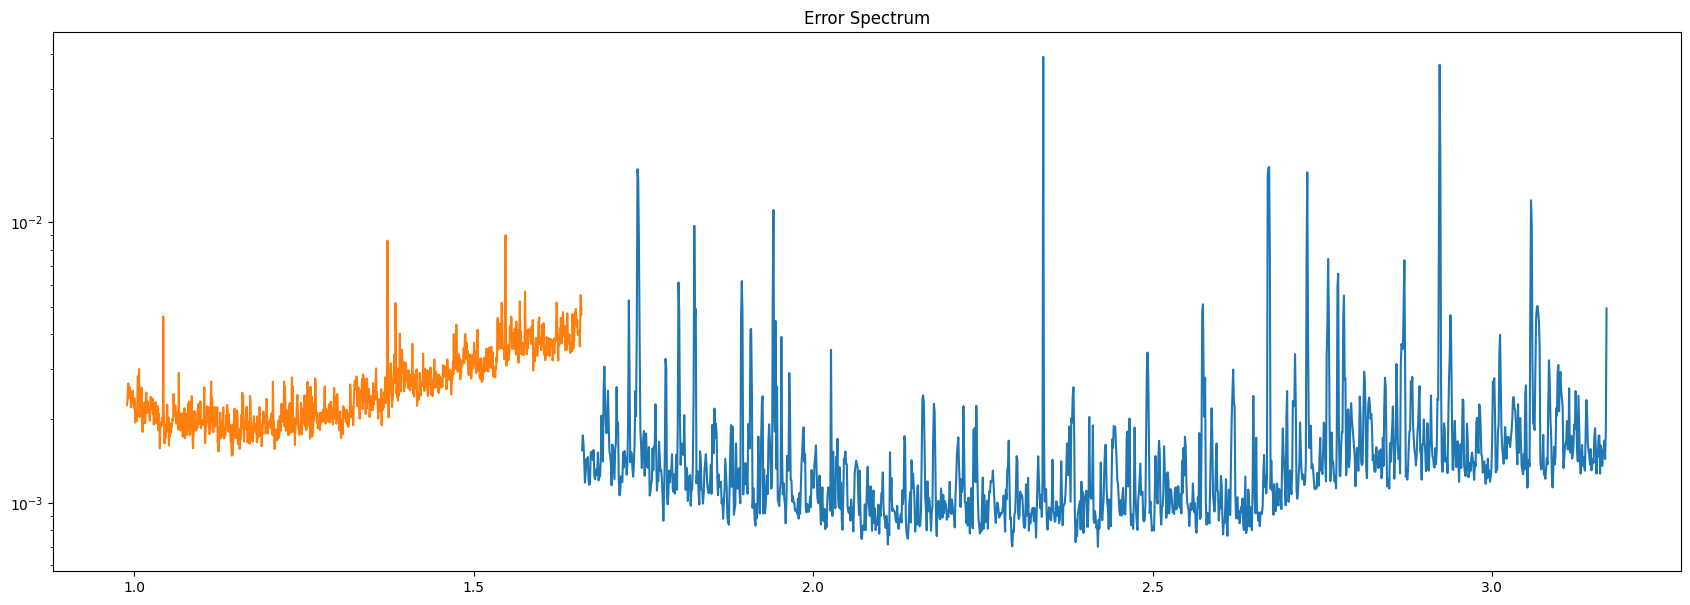

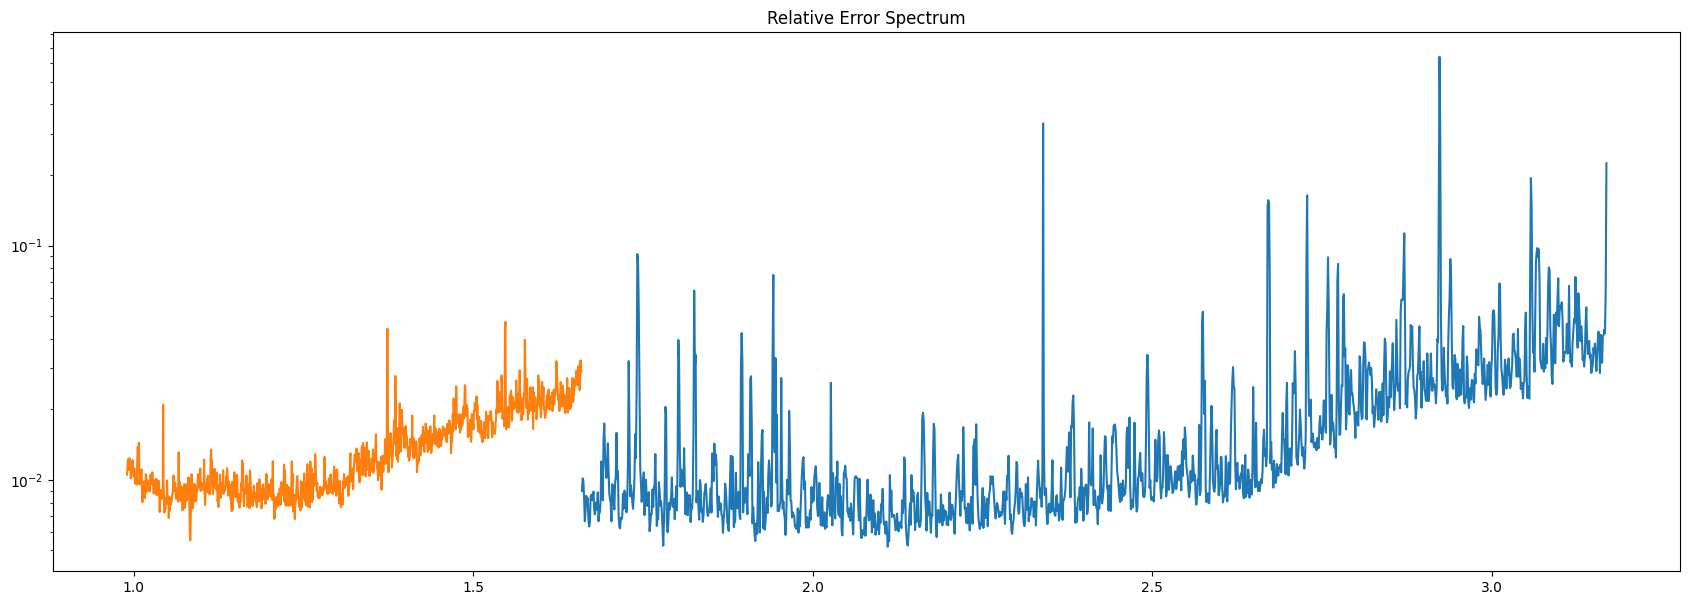

In [86]:
fig, ax = plt.subplots(figsize=(21, 7))
for spec in data:
    ax.plot(spec["lam"], spec["sky"])
ax.set_title("Sky Spectrum")

fig, ax = plt.subplots(figsize=(21, 7))
for spec in data:
    ax.plot(spec["lam"], spec["error"])
ax.set_yscale("log")
ax.set_title("Error Spectrum")

fig, ax = plt.subplots(figsize=(21, 7))
for spec in data:
    ax.plot(spec["lam"], spec["error"]/spec["sky"])
ax.set_yscale("log")
ax.set_title("Relative Error Spectrum")

In [87]:
all_errors = np.concatenate([spec["error"] for spec in data])
print(np.min(all_errors), 
      np.quantile(all_errors, [0.05, 0.5, 0.95]),
      np.max(all_errors))

0.0006984961324977879 [0.00086688 0.00178047 0.00400446] 0.03896235012162313


(0.0, 0.01)

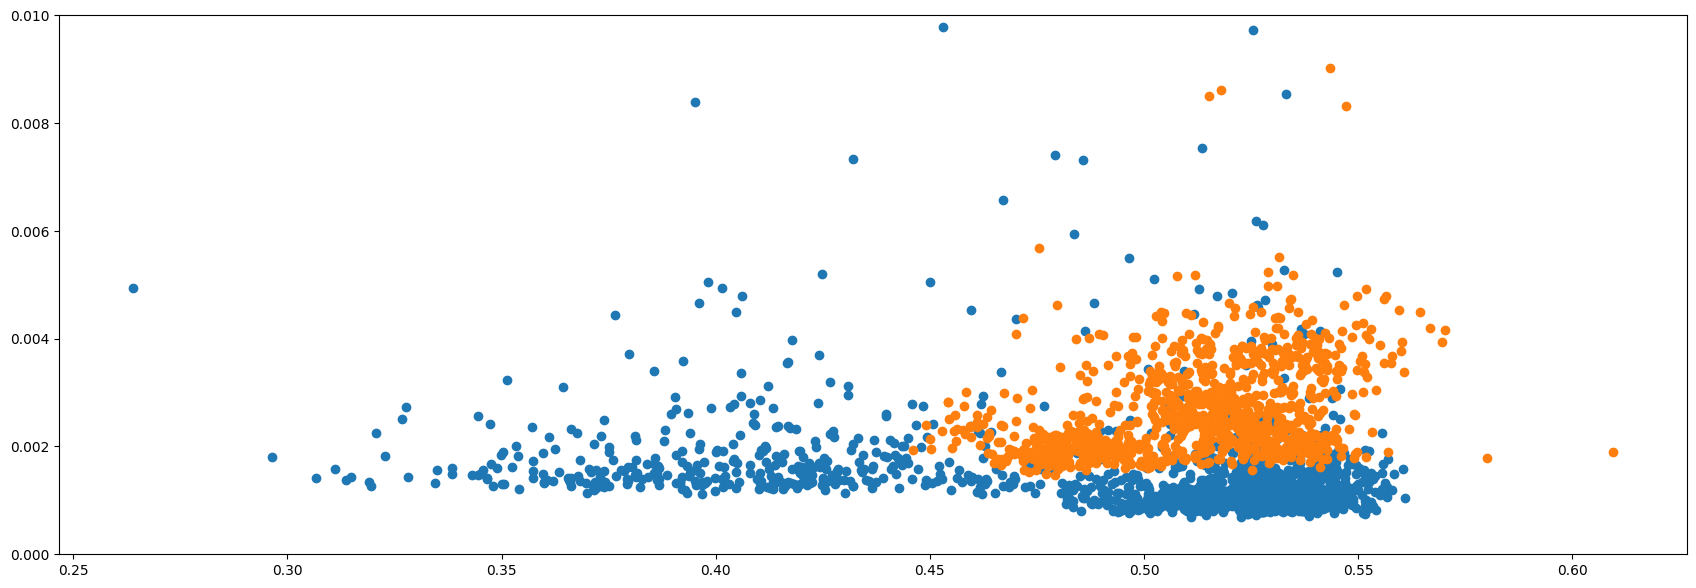

In [88]:
fig, ax = plt.subplots(figsize=(21, 7))
for spec in data:
    arg = np.sqrt(spec["sky"]*spec["lam"])
    ax.plot(arg, spec["error"], linestyle="None", marker="o")

ax.set_ylim(0, 0.01)

### Estimate exposure from first principles 

In [89]:
print([spec["int_time"] for spec in data])
tint = np. mean([spec["int_time"] for spec in data])
tint

[1896.5557, 1167.1112]


1531.83345

In [90]:
print([spec["res"] for spec in data])
res = np. mean([spec["res"] for spec in data])
res

[0.00235406953795375, 0.0014040176344209232]


0.0018790435861873365

In [91]:
for spec in data:
    dlam = spec["lam"][1:]-spec["lam"][:-1]
    print(np.unique(dlam))

[0.00105957 0.00105957 0.00105957]
[0.00063574 0.00063574 0.00063574]


In [92]:
print([spec["grating"] for spec in data])

['G235M', 'G140M']


Text(0.5, 1.0, 'Error Spectrum')

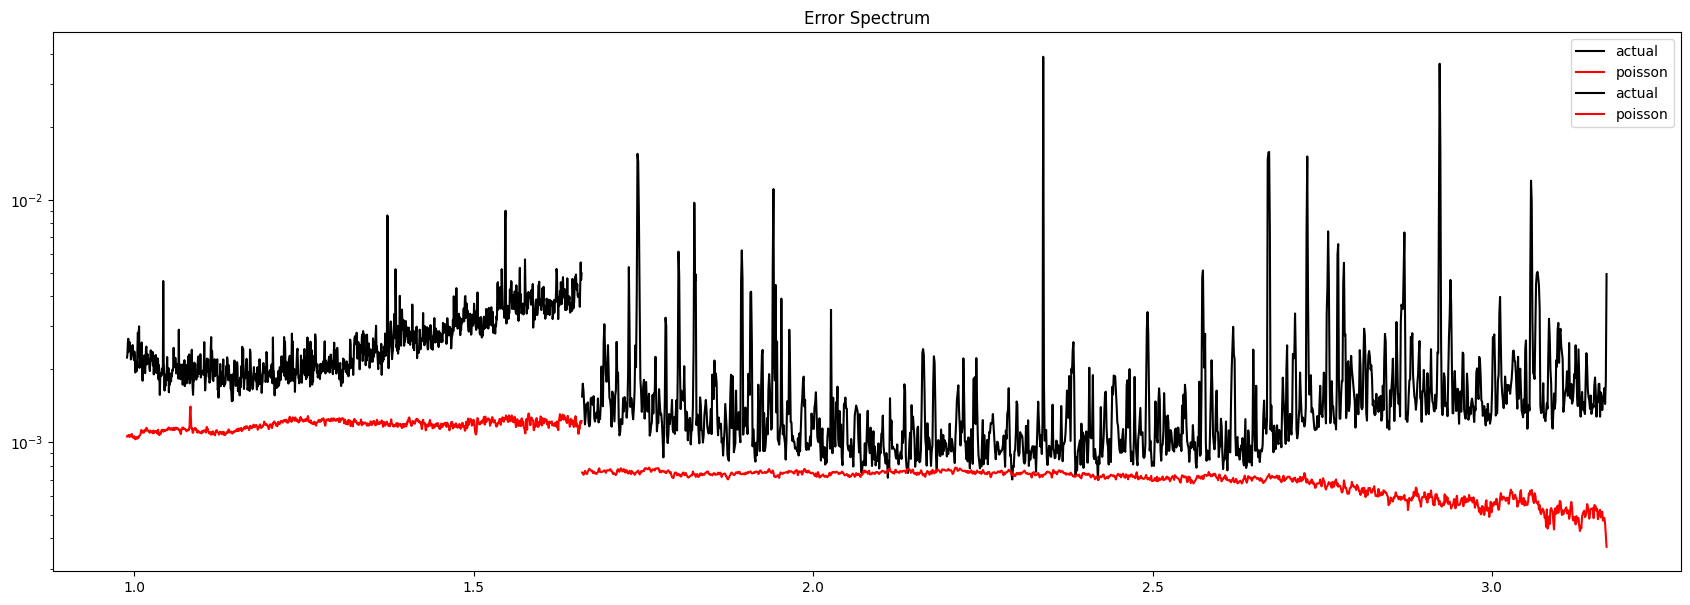

In [93]:
scales = [0.0014, 0.0023]  # see mathematica
fig, ax = plt.subplots(figsize=(21, 7))
for scale, spec in zip(scales, data):
    ax.plot(spec["lam"], spec["error"], label="actual", color="black")
    ax.plot(spec["lam"], scale*np.sqrt(spec["sky"]*spec["lam"]),
            color='red', label="poisson")
ax.legend()
ax.set_yscale("log")
ax.set_title("Error Spectrum")

In [141]:
data0 = fits.open(data[0]["path"])
data0[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  140 / length of dimension 1                          
NAXIS2  =                 1425 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   18 / number of table fields                         
EXTNAME = 'EXTRACT1D'          / extension name                                 
EXTVER  =                    1 / extension value                                
TTYPE1  = 'WAVELENGTH'                                                          
TFORM1  = 'D       '                                                            
TUNIT1  = 'um      '        

In [142]:
data0[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2023-08-26T10:12:28.082' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw04426-o001_t001_nirspec_g235m-f170lp_x1d.fits' / Name of the file  
SDP_VER = '2023_2a '           / Data processing (DP) Software Version          
PRD_VER = 'PRDOPSSOC-062'      / S&OC Project Reference Database (PRD) Version  
OSS_VER = '8.6     '           / Observatory Scheduling Software (OSS) Version  
GSC_VER = 'GSC2431 '        

In [144]:
data0[1].data["FLUX_VAR_POISSON"]

array([0., 0., 0., ..., 0., 0., 0.])

SB_VAR_POISSON 0.0
SB_VAR_RNOISE 0.0
SB_VAR_FLAT 0.0
SB_VAR_POISSON 0.0
SB_VAR_RNOISE 0.0
SB_VAR_FLAT 0.0


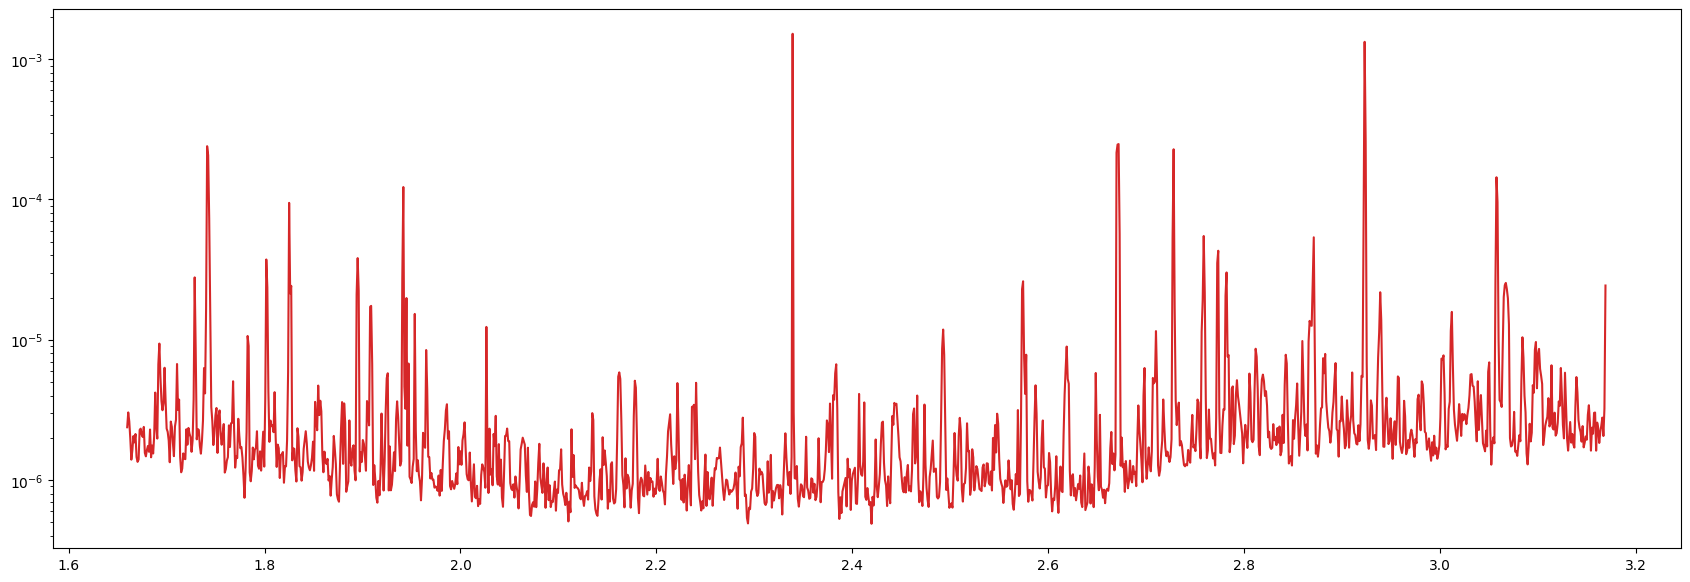

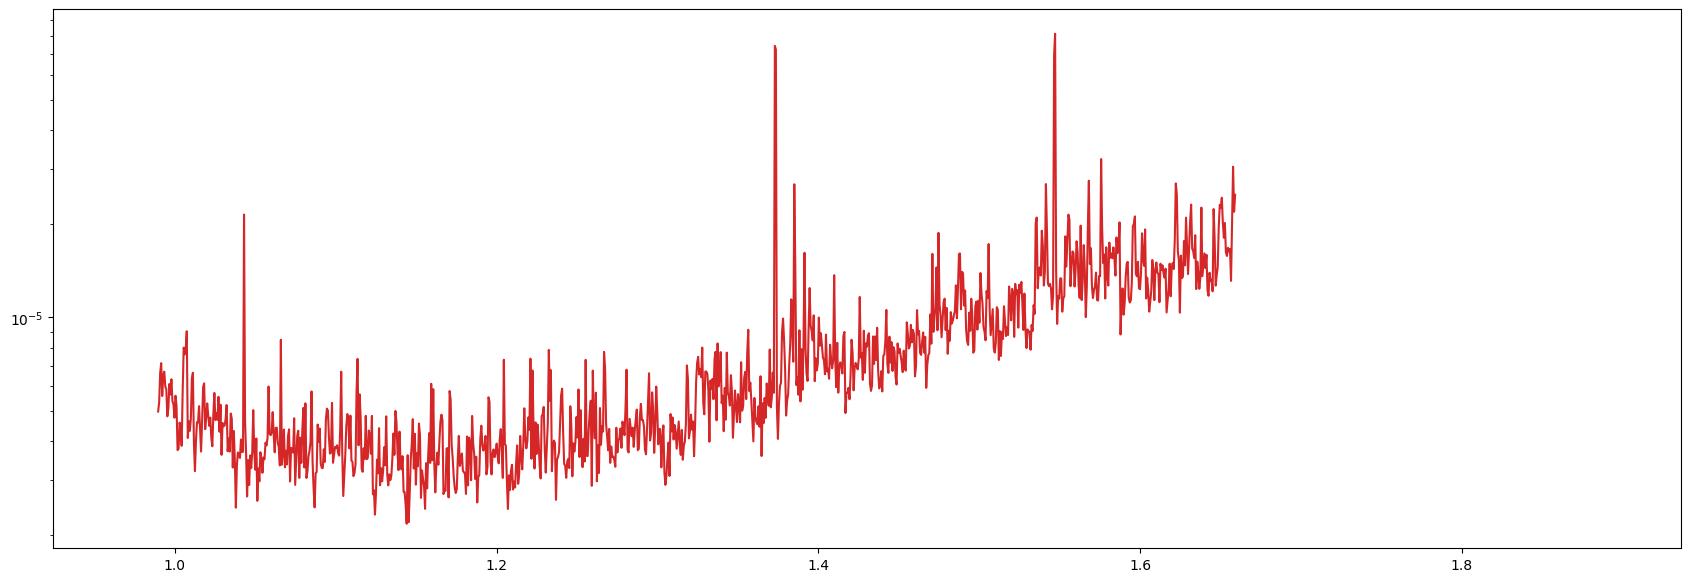

In [107]:
'SB_ERROR'    
components = ['SB_VAR_POISSON',
              'SB_VAR_RNOISE',
              'SB_VAR_FLAT']
for spec in data:
    fig, ax = plt.subplots(figsize=(21, 7))
    hdulist = fits.open(spec["path"])
    l = hdulist[1].data["WAVELENGTH"]
    vars = []
    for comp in components:
        v = hdulist[1].data[comp]
        print(comp, np.max(v))
        vars.append(v)
        ax.plot(l, v, label=comp)
    ax.plot(spec["lam"], spec["error"]**2, label="actual")
    ax.plot(l, np.sum(vars, axis=0), label="total")
    ax.set_yscale("log")

In [102]:
v.max()

0.0

## Check brighter source

In [76]:
instruments = ["g140m", "g235m"]
big_data_dir = "../../JWST2/repo/data/mastDownload/JWST"
all_paths = []
for d in os.listdir(big_data_dir):
    if any(s in d for s in instruments):
        for f in os.listdir(f"{big_data_dir}/{d}"):
            if f.endswith("_x1d.fits"):
                all_paths.append(f"{big_data_dir}/{d}/{f}")
print(f"found {len(all_paths)} files")

found 4680 files


In [162]:
poisson_error = np.full(len(all_paths), np.nan)
for i, p in tqdm(enumerate(all_paths), total=len(all_paths)):
    hdulist = fits.open(p)
    poisson_error[i] = np.median(hdulist[1].data["SB_VAR_POISSON"])

100%|██████████| 4680/4680 [02:17<00:00, 34.01it/s]


In [167]:
np.quantile(poisson_error, [0.05, 0.5, 0.95])

array([nan, nan, nan])

In [173]:
np.any(np.isfinite(poisson_error[poisson_error != 0]))

False

In [155]:
flux_order = np.argsort(med_flux)[::-1]

In [156]:
i_max = flux_order[1]
path_max = all_paths[i_max]
print(i_max, med_flux[i_max])

3021 1809.9955923108087


In [157]:
hdulist = fits.open(path_max)
hdulist[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  140 / length of dimension 1                          
NAXIS2  =                 1447 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   18 / number of table fields                         
EXTNAME = 'EXTRACT1D'          / extension name                                 
EXTVER  =                    1 / extension value                                
TTYPE1  = 'WAVELENGTH'                                                          
TFORM1  = 'D       '                                                            
TUNIT1  = 'um      '        

In [158]:
hdulist[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2023-11-05T19:29:09.003' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01538-o062_t002_nirspec_g140m-f100lp_x1d.fits' / Name of the file  
SDP_VER = '2023_2a '           / Data processing (DP) Software Version          
PRD_VER = 'PRDOPSSOC-063'      / S&OC Project Reference Database (PRD) Version  
OSS_VER = '8.4.11  '           / Observatory Scheduling Software (OSS) Version  
GSC_VER = 'GSC2431 '        

/tmp/ipykernel_9705/3589196667.py:14: RuntimeWarning: invalid value encountered in divide
  ax.plot(lam, sigma_sb/sb)
/tmp/ipykernel_9705/3589196667.py:18: RuntimeWarning: invalid value encountered in sqrt
  ax.plot(np.sqrt(lam*sb), sigma_sb, linestyle="None", marker="o")


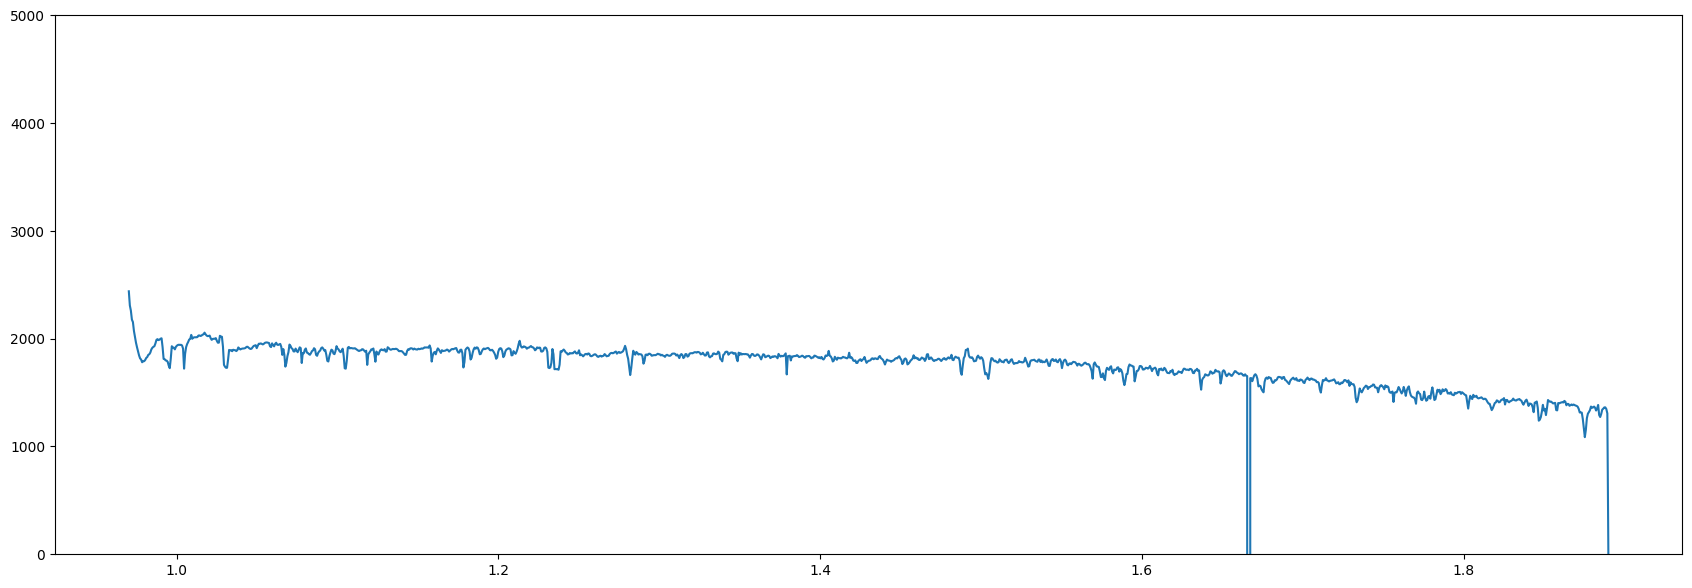

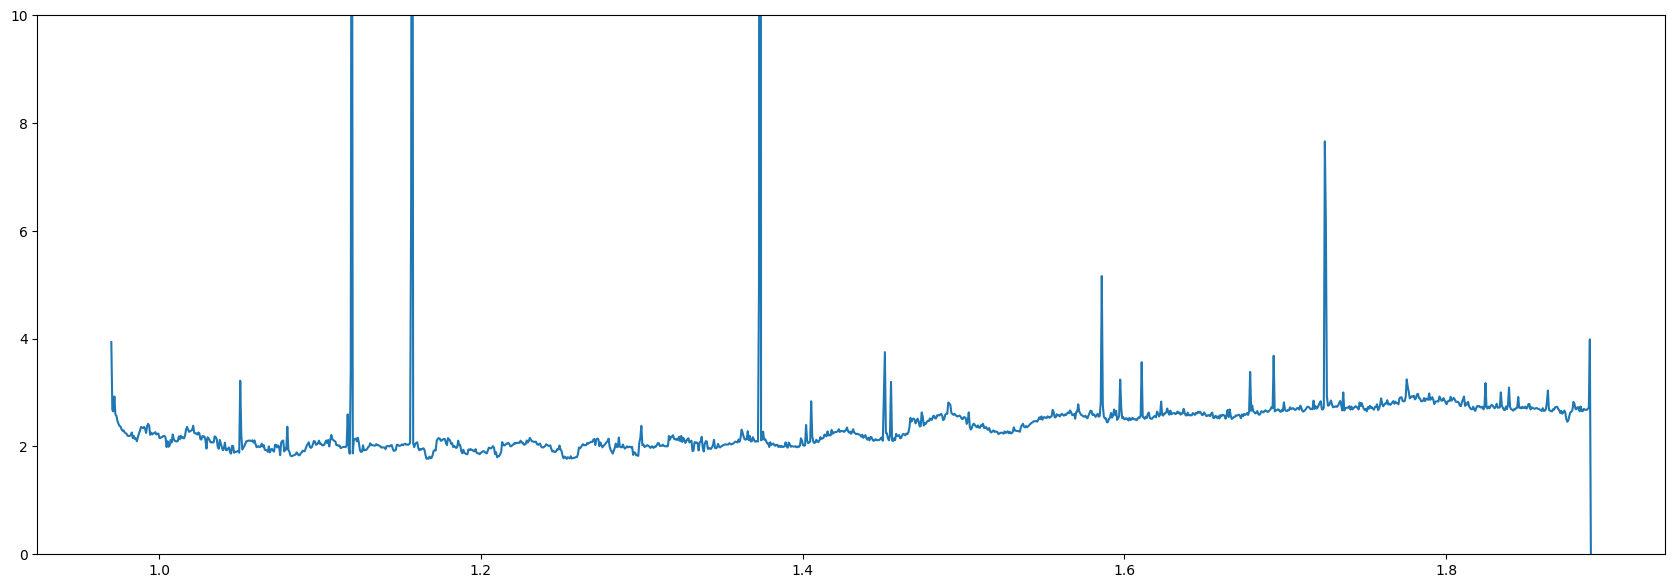

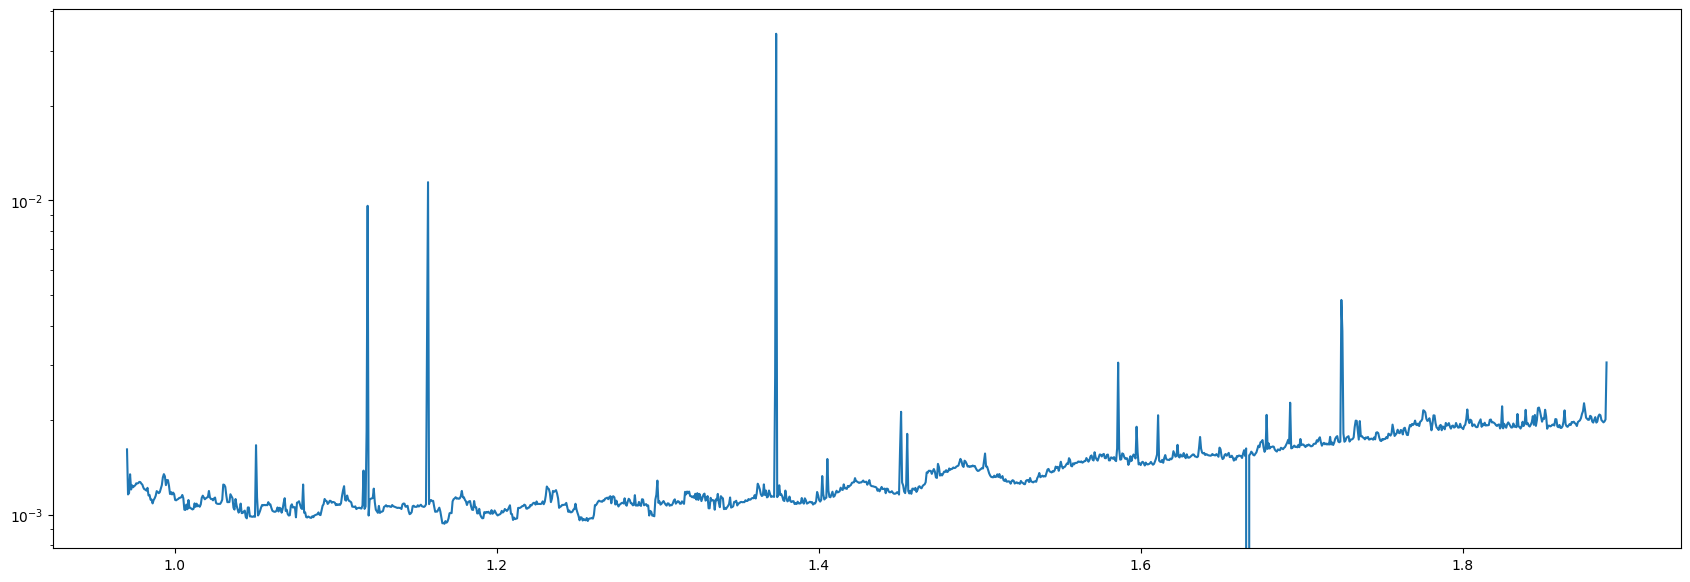

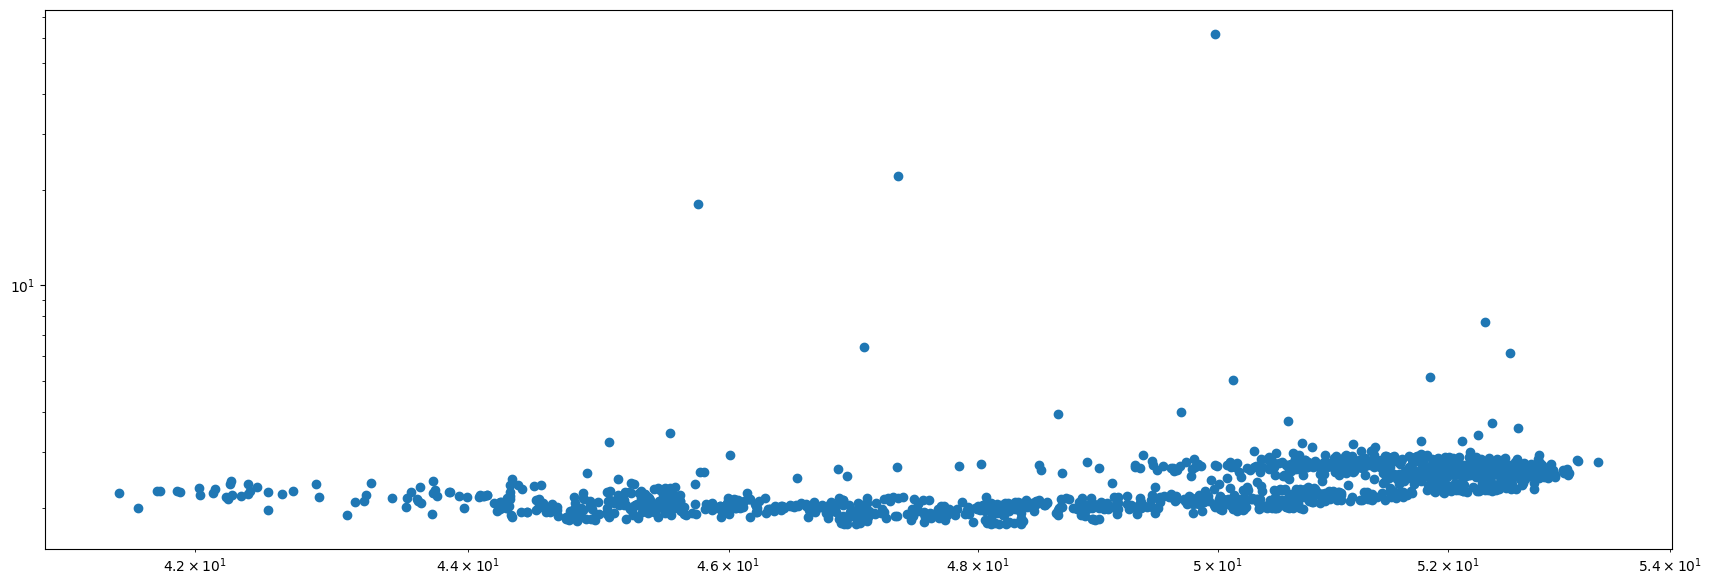

In [161]:
sb = hdulist[1].data["SURF_BRIGHT"]
sigma_sb = hdulist[1].data["SB_ERROR"]
lam = hdulist[1].data["WAVELENGTH"]

fig, ax = plt.subplots(figsize=(21, 7))
ax.plot(lam, sb)
ax.set_ylim(0, 5000)

fig, ax = plt.subplots(figsize=(21, 7))
ax.plot(lam, sigma_sb)
ax.set_ylim(0, 10)

fig, ax = plt.subplots(figsize=(21, 7))
ax.plot(lam, sigma_sb/sb)
ax.set_yscale('log')

fig, ax = plt.subplots(figsize=(21, 7))
ax.plot(np.sqrt(lam*sb), sigma_sb, linestyle="None", marker="o")
ax.set_yscale('log')
ax.set_xscale('log')